# Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import Dataset 

In [2]:
# Load dan tampilkan dataset
df = pd.read_excel('Dataset 2.xlsx')

df

,No,Tanggal,Unit,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3)
0,1,2024-08-01,1,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452
1,2,2024-08-02,1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812
2,3,2024-08-03,1,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701
3,4,2024-08-04,1,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674
4,5,2024-08-05,1,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,545,2026-01-27,1,488.715044,122.735621,791.996076,103745.535498,6.027527,12.955925,108.685235,-0.287959,498.582860,49.763117,7.591082
545,546,2026-01-28,1,485.453714,141.549158,792.244088,102865.219610,6.173781,12.270126,106.464384,-0.221320,472.191265,49.763391,7.572601
546,547,2026-01-29,1,492.223928,150.265522,792.396151,103531.566803,6.020364,12.097462,102.674362,-0.106860,465.546617,49.768304,7.570885
547,548,2026-01-30,1,500.705083,135.204496,791.685285,105029.048393,5.799353,12.569459,108.668248,-0.113589,483.710499,49.766662,7.570648


DATASET STATISTICS FOR 'Dataset 1.xlsx'
Dataset shape: 549 rows, 14 columns

First 5 rows of the dataset:
   No    Tanggal  Unit  SO2 (mg/nm3)  Nox (mg/nm3)  CO (mg/nm3)  \
0   1 2024-08-01     1    467.109710    215.343399   675.494230   
1   2 2024-08-02     1    487.997713    186.102138   677.919792   
2   3 2024-08-03     1    498.073246    188.988139   679.644721   
3   4 2024-08-04     1    503.058633    194.010835   682.033313   
4   5 2024-08-05     1    450.895453    132.718747   478.544209   

       CO2 (ppm)    O2 (%)  Velocity (m/s)  Temp. (°C)  Pressure (Kpa)  \
0  104149.435825  5.733319       13.543683  103.555908       -0.268340   
1  106112.301201  5.007743       12.093034   99.353094       -0.254642   
2  106005.810713  4.783563       11.900385   95.308560       -0.248897   
3  104089.430589  4.842330       11.613680   87.355418       -0.225933   
4   98360.057466  5.686940       12.103985   89.364968       -0.235743   

   Flow rate (KNm3/h)  Opacity (%)  Dust (mg/n

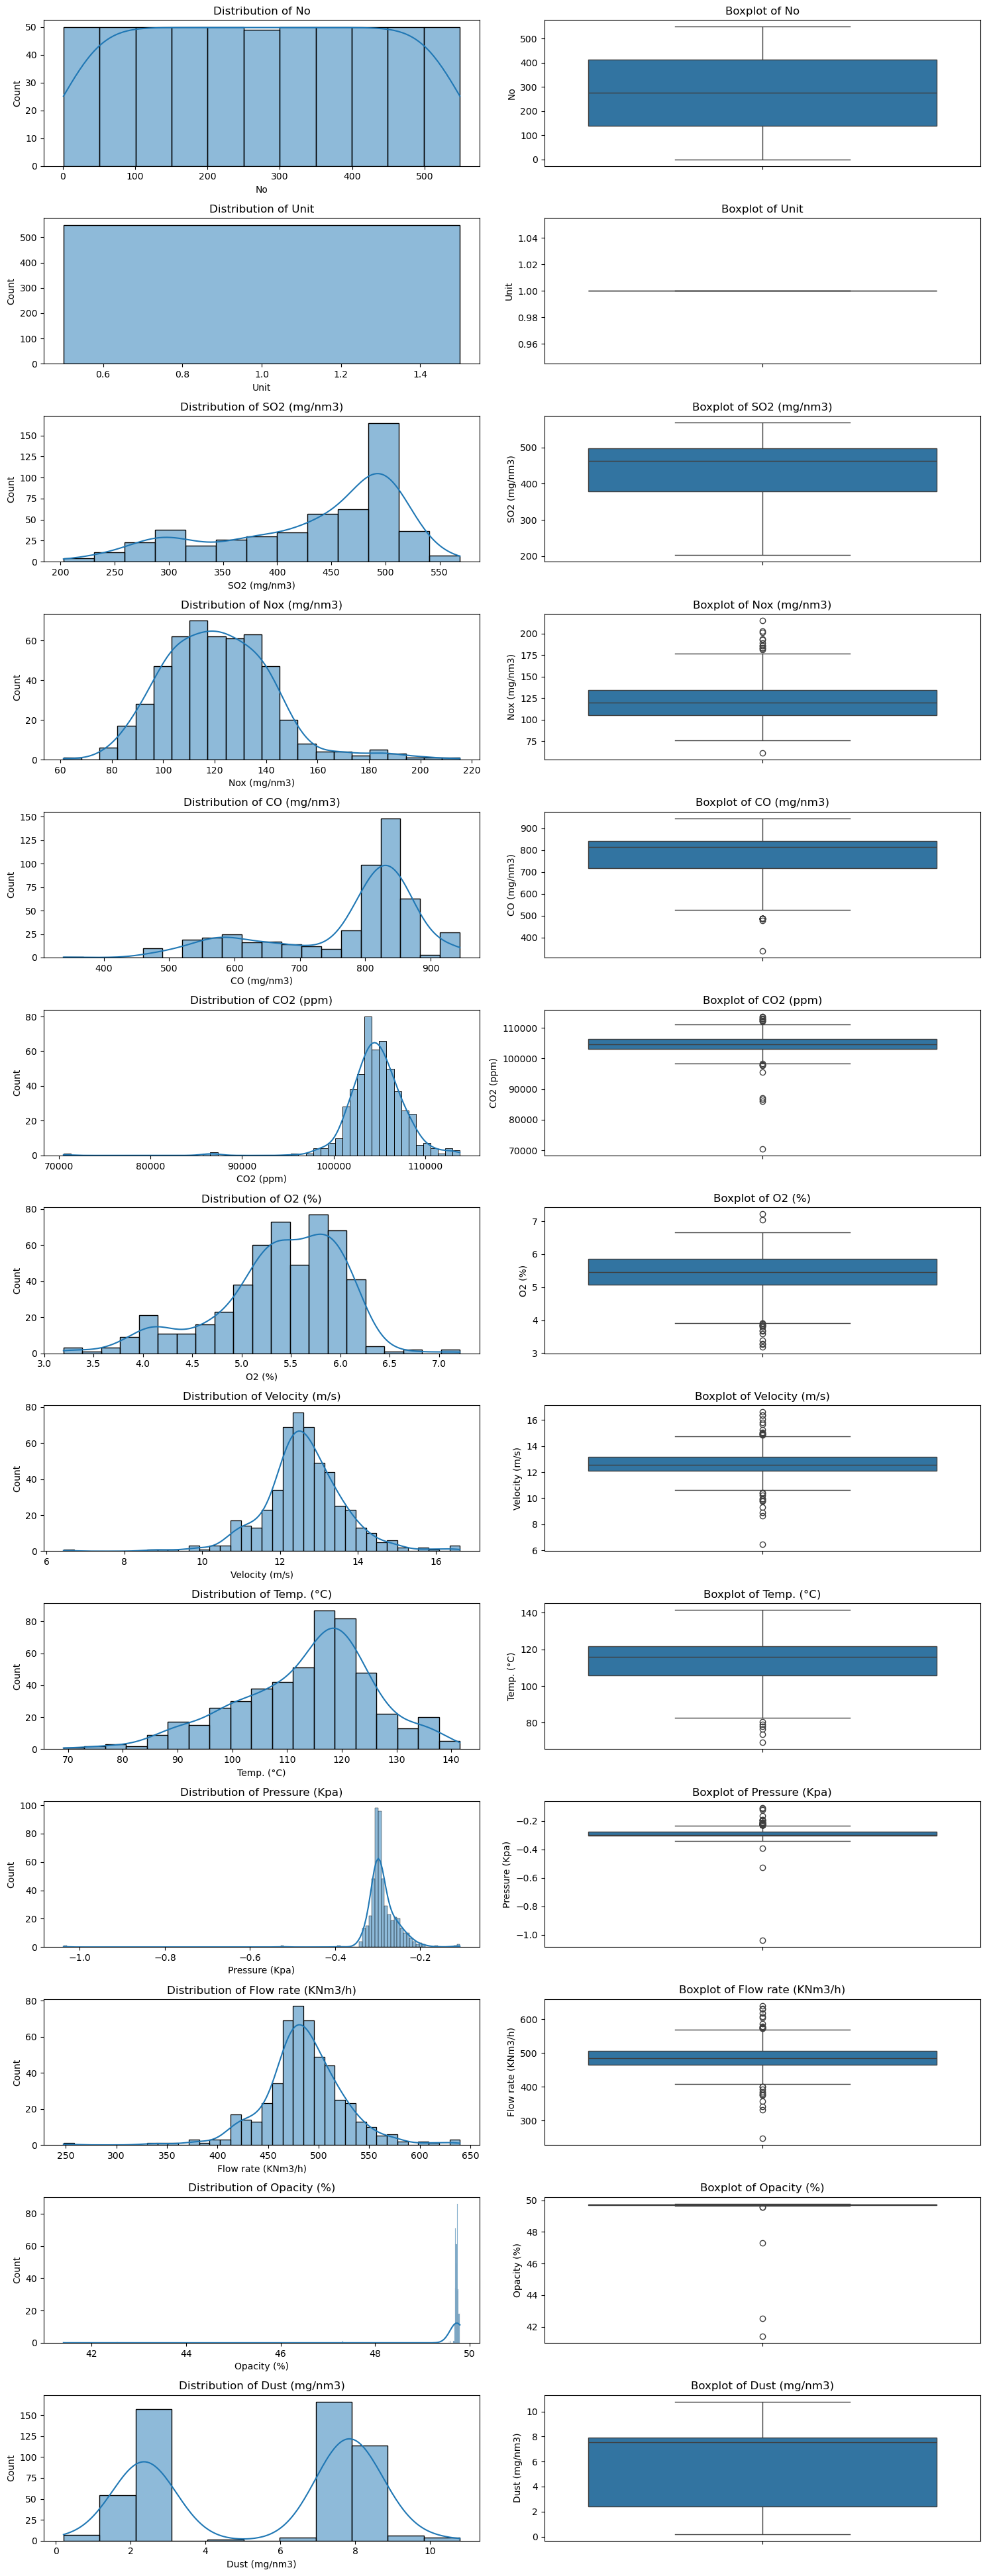


Correlation Matrix:


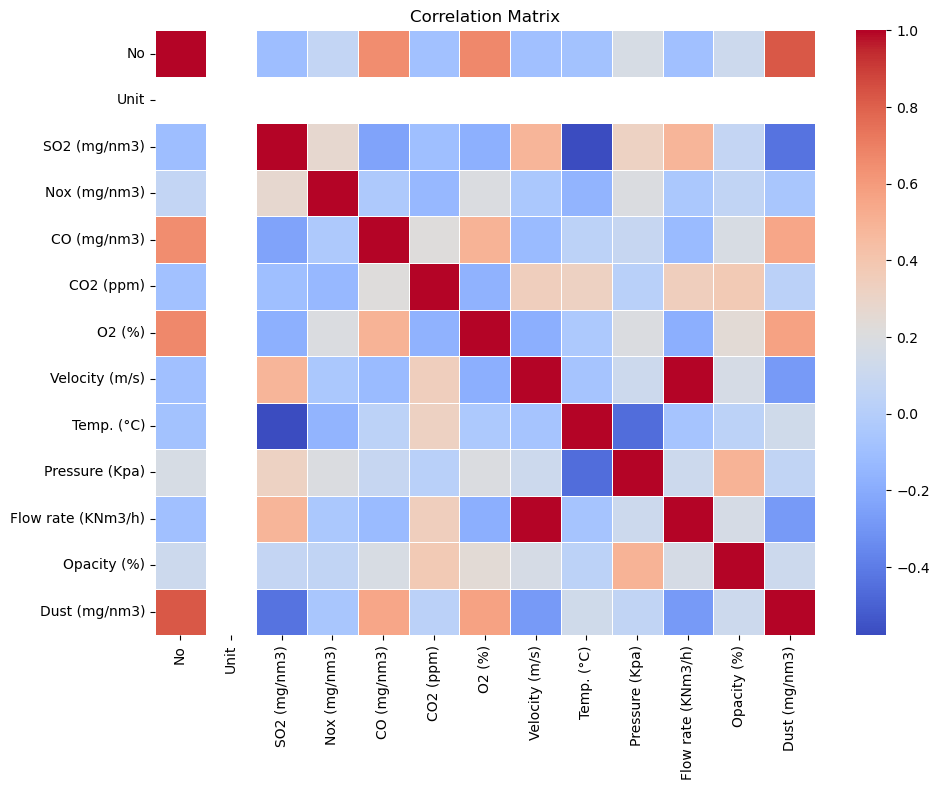

In [3]:
# Load the dataset
df = pd.read_excel('Dataset 2.xlsx')

# Function to display comprehensive dataset statistics
def display_dataset_statistics(df):
    print("="*50)
    print("DATASET STATISTICS FOR 'Dataset 1.xlsx'")
    print("="*50)
    
    # Basic information
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    
    # Display first few rows
    print("First 5 rows of the dataset:")
    print(df.head())
    print("\n")
    
    # Display data types
    print("Data Types:")
    print(df.dtypes)
    print("\n")
    
    # # Check for missing values
    # missing_values = df.isnull().sum()
    # print("Missing Values:")
    # print(missing_values[missing_values > 0] if missing_values.any() > 0 else "No missing values")
    # print("\n")
    
    # Descriptive statistics for numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("Descriptive Statistics for Numerical Columns:")
        print(df[numeric_cols].describe().T)
        print("\n")
        
        # Create histograms for numerical columns
        plt.figure(figsize=(15, len(numeric_cols) * 3))
        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(len(numeric_cols), 2, i*2-1)
            sns.histplot(df[col], kde=True)
            plt.title(f'Distribution of {col}')
            
            plt.subplot(len(numeric_cols), 2, i*2)
            sns.boxplot(y=df[col])
            plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()
    
    # Descriptive statistics for categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("Categorical Columns Summary:")
        for col in cat_cols:
            print(f"\nColumn: {col}")
            value_counts = df[col].value_counts()
            print(f"Number of unique values: {len(value_counts)}")
            print(value_counts.head(10) if len(value_counts) > 10 else value_counts)
        
        # Create bar plots for categorical columns (limit to top 10 categories)
        plt.figure(figsize=(15, len(cat_cols) * 5))
        for i, col in enumerate(cat_cols, 1):
            plt.subplot(len(cat_cols), 1, i)
            top_categories = df[col].value_counts().nlargest(10).index
            sns.countplot(y=df[col][df[col].isin(top_categories)], order=top_categories)
            plt.title(f'Top 10 Categories in {col}')
            plt.tight_layout()
        plt.show()
    
    # Correlation matrix for numerical columns
    if len(numeric_cols) > 1:
        print("\nCorrelation Matrix:")
        corr = df[numeric_cols].corr(method='pearson')
        plt.figure(figsize=(10, 8))
        # mask = np.triu(np.ones_like(corr, dtype=bool))
        # sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
        sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()

# Run the analysis on your dataset
display_dataset_statistics(df)

In [4]:
# Menghapus kolom yang bertipe 'datetime'
df = df.select_dtypes(exclude=['datetime64'])

df

,No,Unit,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3)
0,1,1,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452
1,2,1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812
2,3,1,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701
3,4,1,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674
4,5,1,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,545,1,488.715044,122.735621,791.996076,103745.535498,6.027527,12.955925,108.685235,-0.287959,498.582860,49.763117,7.591082
545,546,1,485.453714,141.549158,792.244088,102865.219610,6.173781,12.270126,106.464384,-0.221320,472.191265,49.763391,7.572601
546,547,1,492.223928,150.265522,792.396151,103531.566803,6.020364,12.097462,102.674362,-0.106860,465.546617,49.768304,7.570885
547,548,1,500.705083,135.204496,791.685285,105029.048393,5.799353,12.569459,108.668248,-0.113589,483.710499,49.766662,7.570648


In [5]:
# Menghapus kolom Unnamed: 0 dan Unit
df = df.drop(['No', 'Unit'], axis=1)  # Put column names in a list when dropping multiple columns

df

,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205
...,...,...,...,...,...,...,...,...,...,...,...
544,488.715044,122.735621,791.996076,103745.535498,6.027527,12.955925,108.685235,-0.287959,498.582860,49.763117,7.591082
545,485.453714,141.549158,792.244088,102865.219610,6.173781,12.270126,106.464384,-0.221320,472.191265,49.763391,7.572601
546,492.223928,150.265522,792.396151,103531.566803,6.020364,12.097462,102.674362,-0.106860,465.546617,49.768304,7.570885
547,500.705083,135.204496,791.685285,105029.048393,5.799353,12.569459,108.668248,-0.113589,483.710499,49.766662,7.570648


In [6]:
# Menampilkan jumlah nilai NaN (missing) per kolom
nan_counts = df.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_counts)

# Menampilkan jumlah nilai nol per kolom
zero_counts = (df == 0).sum()
print("\nJumlah nilai nol per kolom:")
print(zero_counts)

Jumlah nilai NaN per kolom:
SO2 (mg/nm3)          36
Nox (mg/nm3)          36
CO (mg/nm3)           36
CO2 (ppm)             36
O2 (%)                36
Velocity (m/s)        36
Temp. (°C)            36
Pressure (Kpa)        36
Flow rate (KNm3/h)    36
Opacity (%)           36
Dust (mg/nm3)         36
dtype: int64

Jumlah nilai nol per kolom:
SO2 (mg/nm3)          0
Nox (mg/nm3)          0
CO (mg/nm3)           0
CO2 (ppm)             0
O2 (%)                0
Velocity (m/s)        0
Temp. (°C)            0
Pressure (Kpa)        0
Flow rate (KNm3/h)    0
Opacity (%)           0
Dust (mg/nm3)         0
dtype: int64


In [7]:
# Mengganti nilai NaN dengan rata-rata kolom
df = df.fillna(df.mean())

# Mengganti nilai 0 dengan rata-rata kolom
for column in df.columns:
    # Hitung rata-rata tanpa menyertakan nilai 0
    column_mean = df.loc[df[column] != 0, column].mean()
    # Ganti nilai 0 dengan rata-rata
    df.loc[df[column] == 0, column] = column_mean

# Verifikasi bahwa nilai NaN dan 0 telah diganti
print("\nJumlah nilai NaN setelah diganti:")
print(df.isna().sum())
print("\nJumlah nilai 0 setelah diganti:")
print((df == 0).sum())


Jumlah nilai NaN setelah diganti:
SO2 (mg/nm3)          0
Nox (mg/nm3)          0
CO (mg/nm3)           0
CO2 (ppm)             0
O2 (%)                0
Velocity (m/s)        0
Temp. (°C)            0
Pressure (Kpa)        0
Flow rate (KNm3/h)    0
Opacity (%)           0
Dust (mg/nm3)         0
dtype: int64

Jumlah nilai 0 setelah diganti:
SO2 (mg/nm3)          0
Nox (mg/nm3)          0
CO (mg/nm3)           0
CO2 (ppm)             0
O2 (%)                0
Velocity (m/s)        0
Temp. (°C)            0
Pressure (Kpa)        0
Flow rate (KNm3/h)    0
Opacity (%)           0
Dust (mg/nm3)         0
dtype: int64


In [8]:
# Menampilkan jumlah nilai nol per kolom
zero_counts = (df == 0).sum()
print("\nJumlah nilai nol per kolom:")
print(zero_counts)


Jumlah nilai nol per kolom:
SO2 (mg/nm3)          0
Nox (mg/nm3)          0
CO (mg/nm3)           0
CO2 (ppm)             0
O2 (%)                0
Velocity (m/s)        0
Temp. (°C)            0
Pressure (Kpa)        0
Flow rate (KNm3/h)    0
Opacity (%)           0
Dust (mg/nm3)         0
dtype: int64


In [9]:
# Menampilkan jumlah baris yang semua nilai nya adalah nol
zero_rows = (df == 0).all(axis=1).sum()
print(f"\nJumlah baris yang semua nilai nya adalah nol: {zero_rows}")


Jumlah baris yang semua nilai nya adalah nol: 0


In [10]:
# Menampilkan jumlah baris yang mengandung setidaknya satu nilai nol
zero_rows_any = (df == 0).any(axis=1).sum()
print(f"\nJumlah baris yang mengandung setidaknya satu nilai nol: {zero_rows_any}")


Jumlah baris yang mengandung setidaknya satu nilai nol: 0


In [11]:
df

,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3)
0,467.109710,215.343399,675.494230,104149.435825,5.733319,13.543683,103.555908,-0.268340,521.201534,49.690183,0.269452
1,487.997713,186.102138,677.919792,106112.301201,5.007743,12.093034,99.353094,-0.254642,465.376223,49.691542,0.270812
2,498.073246,188.988139,679.644721,106005.810713,4.783563,11.900385,95.308560,-0.248897,457.962513,49.697809,0.272701
3,503.058633,194.010835,682.033313,104089.430589,4.842330,11.613680,87.355418,-0.225933,446.929254,49.702891,0.274674
4,450.895453,132.718747,478.544209,98360.057466,5.686940,12.103985,89.364968,-0.235743,465.797638,49.688853,0.283205
...,...,...,...,...,...,...,...,...,...,...,...
544,488.715044,122.735621,791.996076,103745.535498,6.027527,12.955925,108.685235,-0.287959,498.582860,49.763117,7.591082
545,485.453714,141.549158,792.244088,102865.219610,6.173781,12.270126,106.464384,-0.221320,472.191265,49.763391,7.572601
546,492.223928,150.265522,792.396151,103531.566803,6.020364,12.097462,102.674362,-0.106860,465.546617,49.768304,7.570885
547,500.705083,135.204496,791.685285,105029.048393,5.799353,12.569459,108.668248,-0.113589,483.710499,49.766662,7.570648


In [12]:
df.describe()

,SO2 (mg/nm3),Nox (mg/nm3),CO (mg/nm3),CO2 (ppm),O2 (%),Velocity (m/s),Temp. (°C),Pressure (Kpa),Flow rate (KNm3/h),Opacity (%),Dust (mg/nm3)
count,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000,549.000000
mean,432.598611,121.350162,773.775742,104594.961021,5.380965,12.604040,113.536644,-0.288601,485.041257,49.691747,5.513436
std,79.613273,20.692030,109.243272,3208.108939,0.617149,1.015804,12.049538,0.045180,39.091200,0.480254,2.724396
min,202.769128,61.237383,338.437718,70509.647274,3.194799,6.435968,69.170952,-1.038286,247.675349,41.407412,0.204475
25%,386.400365,106.719629,742.686594,103214.808617,5.129465,12.148013,106.873303,-0.303721,467.491975,49.702054,2.461368
50%,453.231619,121.350162,809.258996,104594.961021,5.413480,12.604040,115.184237,-0.293829,485.041257,49.722612,7.512560
75%,496.124840,133.407363,841.117994,106145.260189,5.840079,13.098576,121.062657,-0.276941,504.072503,49.739346,7.879734
max,568.768529,215.343399,944.769940,113768.549839,7.212713,16.620267,141.580422,-0.106860,639.597720,49.792566,10.798639


DATASET STATISTICS FOR 'Dataset 1.xlsx'
Dataset shape: 549 rows, 11 columns

First 5 rows of the dataset:
   SO2 (mg/nm3)  Nox (mg/nm3)  CO (mg/nm3)      CO2 (ppm)    O2 (%)  \
0    467.109710    215.343399   675.494230  104149.435825  5.733319   
1    487.997713    186.102138   677.919792  106112.301201  5.007743   
2    498.073246    188.988139   679.644721  106005.810713  4.783563   
3    503.058633    194.010835   682.033313  104089.430589  4.842330   
4    450.895453    132.718747   478.544209   98360.057466  5.686940   

   Velocity (m/s)  Temp. (°C)  Pressure (Kpa)  Flow rate (KNm3/h)  \
0       13.543683  103.555908       -0.268340          521.201534   
1       12.093034   99.353094       -0.254642          465.376223   
2       11.900385   95.308560       -0.248897          457.962513   
3       11.613680   87.355418       -0.225933          446.929254   
4       12.103985   89.364968       -0.235743          465.797638   

   Opacity (%)  Dust (mg/nm3)  
0    49.690183      

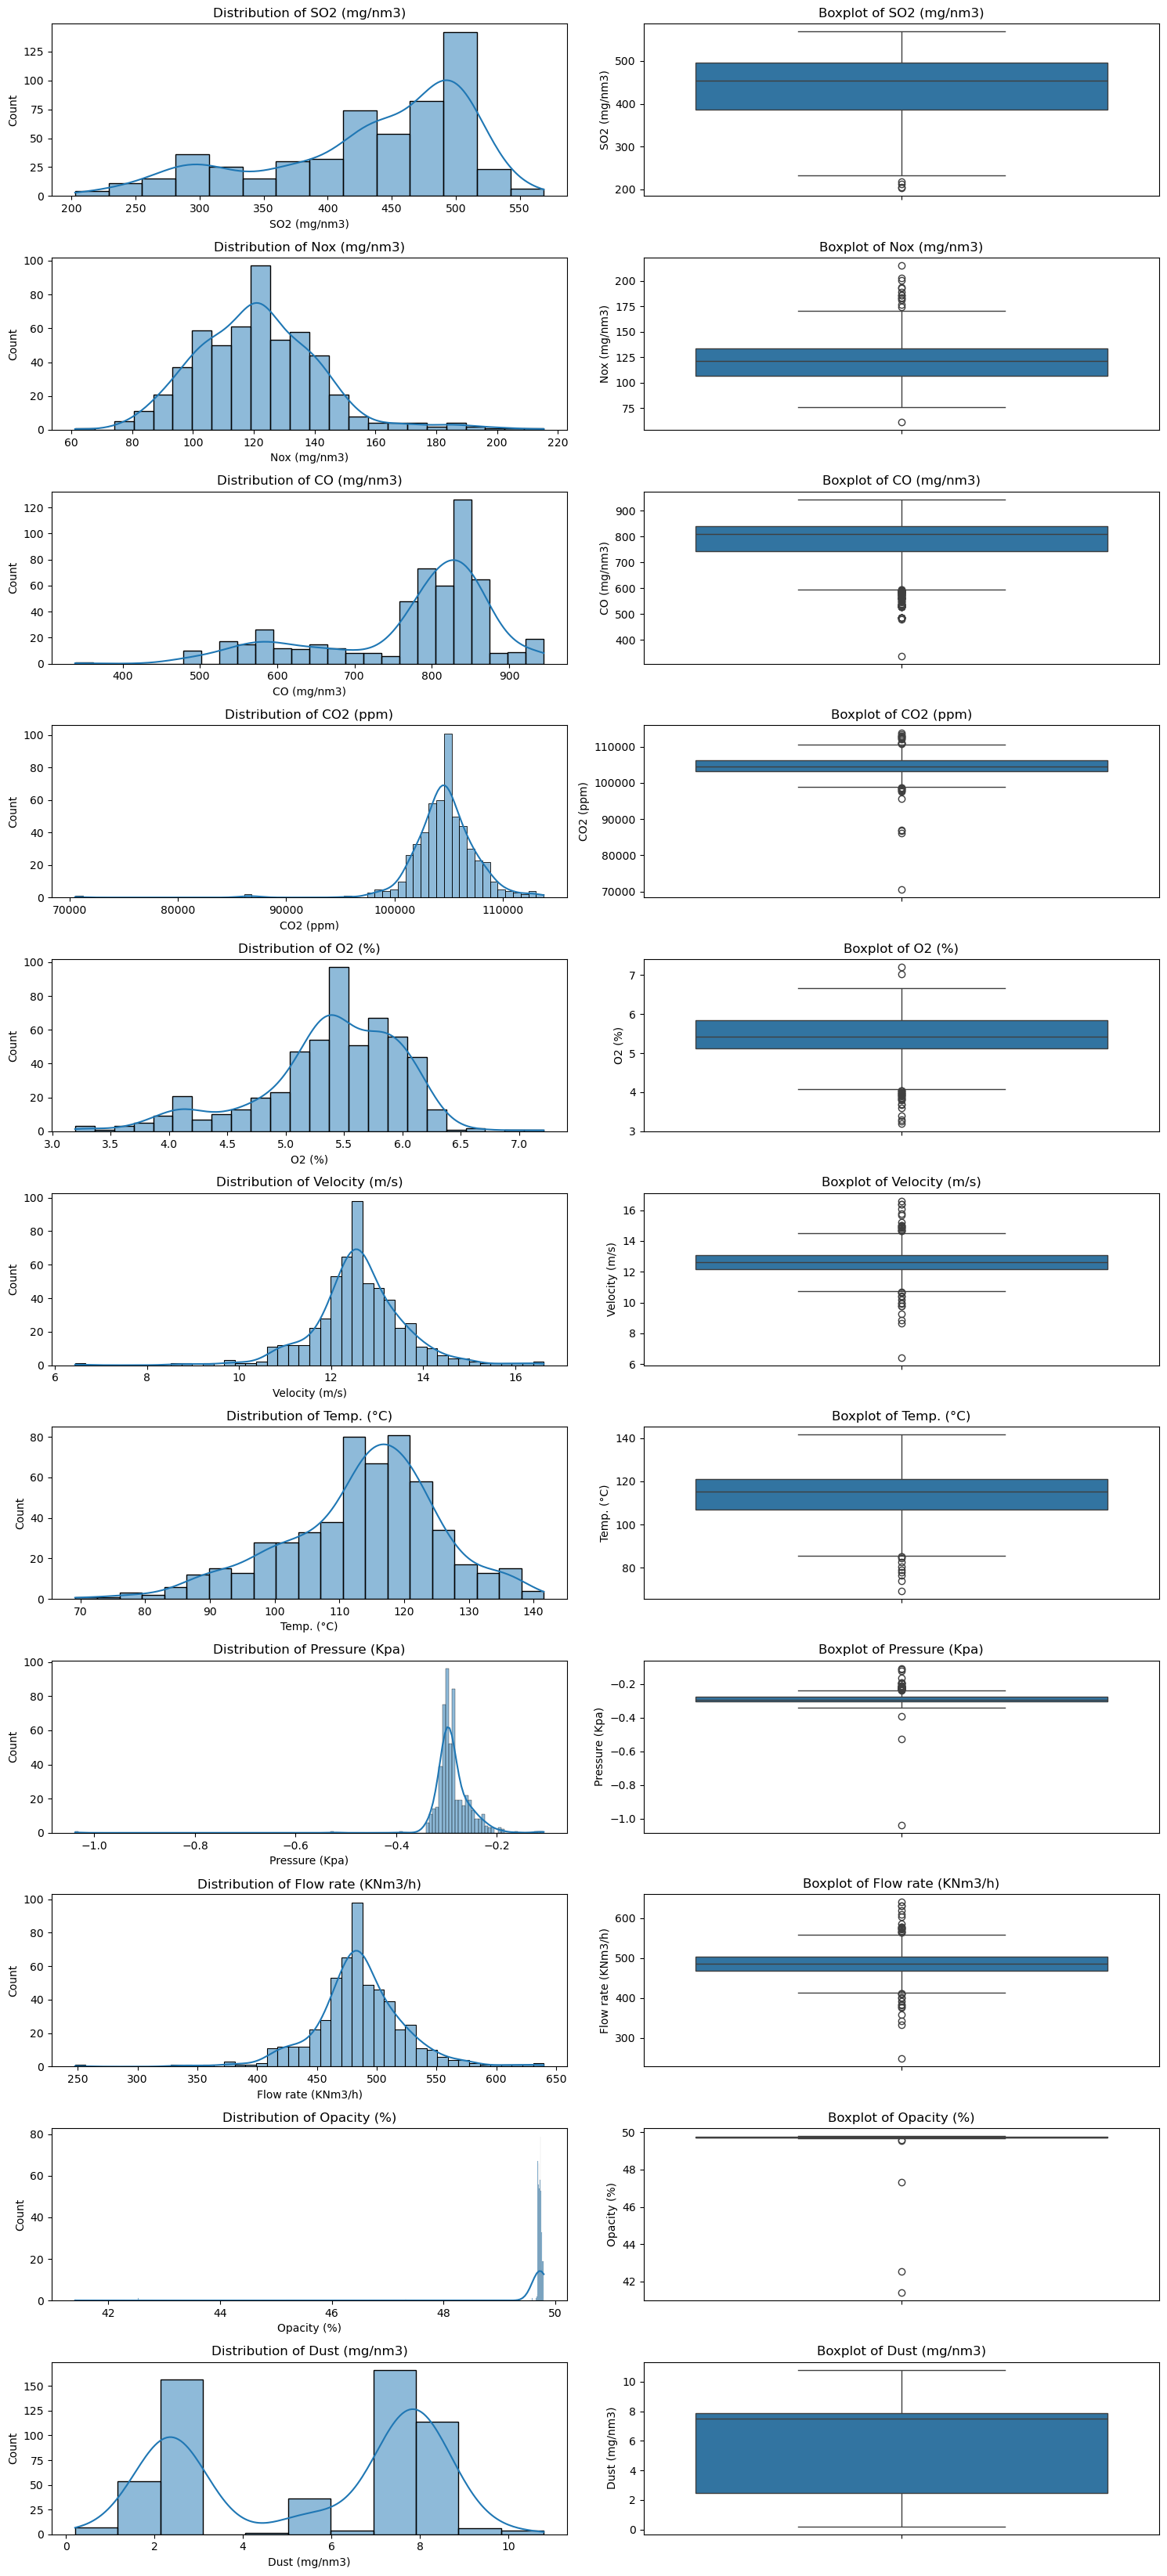


Correlation Matrix:


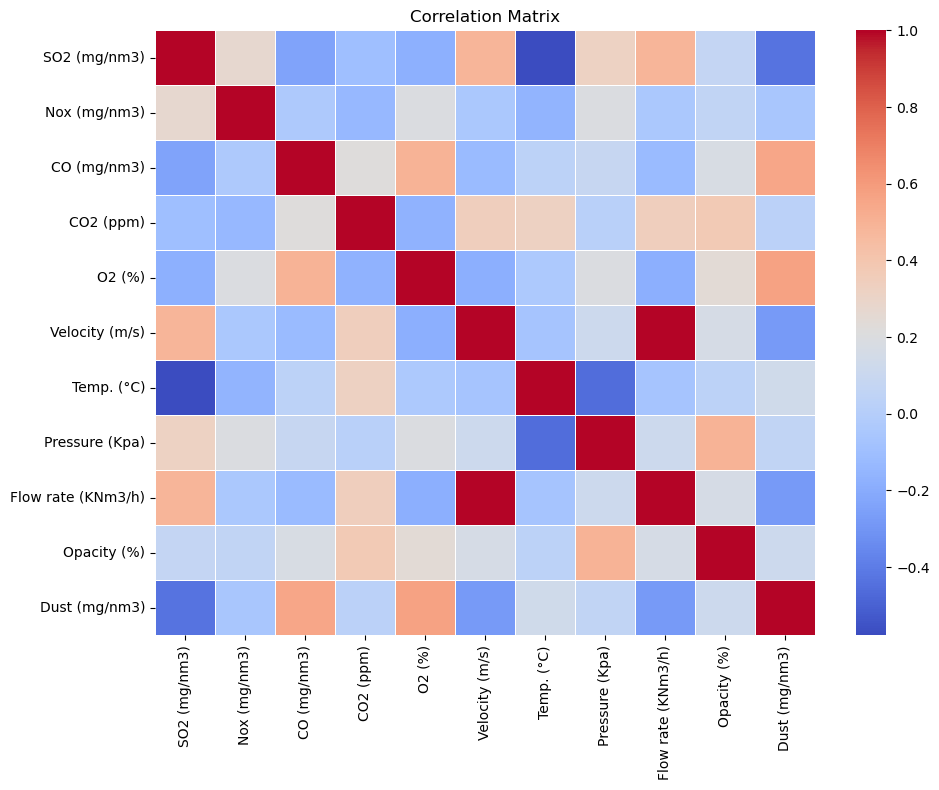

In [13]:
# Function to display comprehensive dataset statistics
def display_dataset_statistics(df):
    print("="*50)
    print("DATASET STATISTICS FOR 'Dataset 1.xlsx'")
    print("="*50)
    
    # Basic information
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
    
    # Display first few rows
    print("First 5 rows of the dataset:")
    print(df.head())
    print("\n")
    
    # Display data types
    print("Data Types:")
    print(df.dtypes)
    print("\n")
    
    # Descriptive statistics for numerical columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("Descriptive Statistics for Numerical Columns:")
        print(df[numeric_cols].describe().T)
        print("\n")
        
        # Create histograms for numerical columns
        plt.figure(figsize=(15, len(numeric_cols) * 3))
        for i, col in enumerate(numeric_cols, 1):
            plt.subplot(len(numeric_cols), 2, i*2-1)
            sns.histplot(df[col], kde=True)
            plt.title(f'Distribution of {col}')
            
            plt.subplot(len(numeric_cols), 2, i*2)
            sns.boxplot(y=df[col])
            plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.show()
    
    # Descriptive statistics for categorical columns
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(cat_cols) > 0:
        print("Categorical Columns Summary:")
        for col in cat_cols:
            print(f"\nColumn: {col}")
            value_counts = df[col].value_counts()
            print(f"Number of unique values: {len(value_counts)}")
            print(value_counts.head(10) if len(value_counts) > 10 else value_counts)
        
        # Create bar plots for categorical columns (limit to top 10 categories)
        plt.figure(figsize=(15, len(cat_cols) * 5))
        for i, col in enumerate(cat_cols, 1):
            plt.subplot(len(cat_cols), 1, i)
            top_categories = df[col].value_counts().nlargest(10).index
            sns.countplot(y=df[col][df[col].isin(top_categories)], order=top_categories)
            plt.title(f'Top 10 Categories in {col}')
            plt.tight_layout()
        plt.show()
    
    # Correlation matrix for numerical columns
    if len(numeric_cols) > 1:
        print("\nCorrelation Matrix:")
        corr = df[numeric_cols].corr(method='pearson')
        plt.figure(figsize=(10, 8))
        # mask = np.triu(np.ones_like(corr, dtype=bool))
        # sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
        sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()

# Run the analysis on your dataset
display_dataset_statistics(df)

In [14]:
# Simpan DataFrame ke dalam file Excel
df.to_excel('Cleaned_Dataset 2.xlsx', index=False)  # `index=False` menghindari penambahan kolom index ke dalam file Excel

print("DataFrame telah disimpan ke dalam file 'Cleaned_Dataset 2.xlsx'")

DataFrame telah disimpan ke dalam file 'Cleaned_Dataset 2.xlsx'
